[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Aplicaciones-Financieras/blob/main/Semana2/2_Autoencoders_DeteccionFraude.ipynb)

# Dependencias

In [ ]:
# Puede no ser necesaria si ya tienen instalado plotly
#!pip install -U plotly

In [ ]:
# Instalar la versión ESPECÍFICA de un módulo
!pip install pandas=='2.1.4'

In [ ]:
# Modulos instalados y sus versiones
!pip list

Package                          Version
-------------------------------- ---------------------
absl-py                          1.4.0
aiohttp                          3.9.5
aiosignal                        1.3.1
alabaster                        0.7.16
albumentations                   1.3.1
altair                           4.2.2
annotated-types                  0.6.0
anyio                            3.7.1
appdirs                          1.4.4
argon2-cffi                      23.1.0
argon2-cffi-bindings             21.2.0
array_record                     0.5.1
arviz                            0.15.1
astropy                          5.3.4
astunparse                       1.6.3
async-timeout                    4.0.3
atpublic                         4.1.0
attrs                            23.2.0
audioread                        3.0.1
autograd                         1.6.2
Babel                            2.14.0
backcall                         0.2.0
beautifulsoup4                   4.12.3


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, mean_squared_error, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import ModelCheckpoint
from keras import regularizers

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

import seaborn as sns

In [ ]:
pio.templates.default = 'plotly_white'

# Datos

Utilizaremos los mismo datos de la clase pasada

https://www.kaggle.com/mlg-ulb/creditcardfraud/data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Cruso-ApsFinancieras/semana3/creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
# El resultado seria 'False' si NO hay valores nulos y sería 'True' si SI hay valores nulos
df.isnull().values.any()

False

In [ ]:
# 0: Normal
# 1: Fraudulento

print(df.Class.value_counts())
df.Class.value_counts() / len(df)

Class
0    284315
1       492
Name: count, dtype: int64


Class
0    0.998273
1    0.001727
Name: count, dtype: float64

In [ ]:
df[df.Class == 0].Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [ ]:
df[df.Class == 1].Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [ ]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df.loc[:, 'V1':'Amount']

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [ ]:
# Separación de características
X = df.iloc[:, 1:-1]
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


In [ ]:
# Variables objetivos
y = df.Class
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
normal_df = df[df.Class == 0]
fraud_df = df[df.Class == 1]

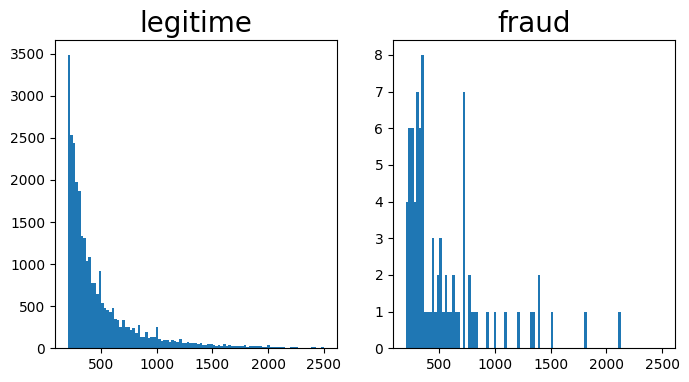

In [ ]:
bins = np.linspace(200, 2500, 100)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

ax = axes.ravel()

ax[0].hist(normal_df.Amount, bins, alpha=1, label='Normal')
ax[0].set_title('legitime', fontsize=20)

ax[1].hist(fraud_df.Amount, bins, alpha=1, label='Fraud')
ax[1].set_title('fraud', fontsize=20)
plt.show()

## División en conjuntos de entrenamiento y prueba

## Estandarización

In [ ]:
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

X

array([[-0.69424232, -0.04407492,  1.6727735 , ...,  0.33089162,
        -0.06378115,  0.24496426],
       [ 0.60849633,  0.16117592,  0.1097971 , ..., -0.02225568,
         0.04460752, -0.34247454],
       [-0.69350046, -0.81157783,  1.16946849, ..., -0.13713686,
        -0.18102083,  1.16068593],
       ...,
       [ 0.98002374, -0.18243372, -2.14320514, ...,  0.01103672,
        -0.0804672 , -0.0818393 ],
       [-0.12275539,  0.32125034,  0.46332013, ...,  0.26960398,
         0.31668678, -0.31324853],
       [-0.27233093, -0.11489898,  0.46386564, ..., -0.00598394,
         0.04134999,  0.51435531]])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10) # train_size=0.8

In [ ]:
X_train_norm = X_train

In [ ]:
X_train.shape, X_test.shape

((227845, 29), (56962, 29))

In [ ]:
y_train.value_counts()/len(y_train)

Class
0    0.998253
1    0.001747
Name: count, dtype: float64

In [ ]:
y_test.value_counts()/len(y_test)

Class
0    0.99835
1    0.00165
Name: count, dtype: float64

"If you torture the data long enough, it will confess" Ronald H. Coase

# Modelo

## Configuración del modelo

In [ ]:
input_dim = X_train_norm.shape[1] # Número de columnas: 29
encoding_dim = 14
hidden_dim = int(encoding_dim / 2)
learning_rate = 1e-4

In [ ]:
input_dim

In [ ]:
print(f'{1e-4: .9f}')

 0.000100000


## Arquitectura de la red

In [ ]:
# Hiperparámetros muy importantes:
# - learning rate
# - batch size

In [ ]:
# Creación de las capas del modelo
input_layer = Input(shape=(29, ))

encoder = Dense(14, activation="relu", activity_regularizer=regularizers.l1(learning_rate))(input_layer)
encoder2 = Dense(7, activation="relu")(encoder)

decoder = Dense(7, activation='relu')(encoder2)
decoder_f = Dense(29, activation='relu')(decoder)


autoencoder = Model(inputs=input_layer, outputs=decoder_f)

In [ ]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 29)]              0         
                                                                 
 dense (Dense)               (None, 14)                420       
                                                                 
 dense_1 (Dense)             (None, 7)                 105       
                                                                 
 dense_2 (Dense)             (None, 7)                 56        
                                                                 
 dense_3 (Dense)             (None, 29)                232       
                                                                 
Total params: 813 (3.18 KB)
Trainable params: 813 (3.18 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
autoencoder.compile(loss='mean_squared_error',
                    optimizer='adam')

### Con las lineas de abajo pueden decidir que epoca de entrenamiento guardar

# cp = ModelCheckpoint(filepath="autoencoder_fraud.keras",
#                                save_best_only=True,
#                                verbose=0)

## Entrenamiento

In [ ]:
history = autoencoder.fit(X_train_norm, X_train_norm,
                          epochs=100,
                          batch_size=2048,
                          shuffle = True,
                          validation_split=.2,
                          verbose=1,
                        #   callbacks = cp
                          ).history

Epoch 1/100
90/90 [==============================] - 2s 6ms/step - loss: 0.9920 - val_loss: 0.9684
Epoch 2/100
90/90 [==============================] - 0s 4ms/step - loss: 0.9517 - val_loss: 0.9247
Epoch 3/100
90/90 [==============================] - 0s 4ms/step - loss: 0.9108 - val_loss: 0.8938
Epoch 4/100
90/90 [==============================] - 0s 4ms/step - loss: 0.8862 - val_loss: 0.8756
Epoch 5/100
90/90 [==============================] - 0s 5ms/step - loss: 0.8689 - val_loss: 0.8613
Epoch 6/100
90/90 [==============================] - 1s 8ms/step - loss: 0.8539 - val_loss: 0.8481
Epoch 7/100
90/90 [==============================] - 1s 7ms/step - loss: 0.8409 - val_loss: 0.8366
Epoch 8/100
90/90 [==============================] - 1s 6ms/step - loss: 0.8292 - val_loss: 0.8265
Epoch 9/100
90/90 [==============================] - 1s 8ms/step - loss: 0.8196 - val_loss: 0.8194
Epoch 10/100
90/90 [==============================] - 1s 7ms/step - loss: 0.8125 - val_loss: 0.8130
Epoch 11/

In [ ]:
90*2048

184320

In [ ]:
# Comando para recuperar los datos guardados del modelos, en este caso se guardaria la mejor epoca nada mas

# autoencoder = load_model('autoencoder_fraud.keras')

## Evaluación

In [ ]:
history

{'loss': [0.9920175075531006,
  0.9516635537147522,
  0.9108189344406128,
  0.8862091302871704,
  0.868923544883728,
  0.8539337515830994,
  0.8409056663513184,
  0.8291683793067932,
  0.8195681571960449,
  0.8125148415565491,
  0.8065225481987,
  0.8010596632957458,
  0.7958919405937195,
  0.7907788753509521,
  0.785605788230896,
  0.7803394794464111,
  0.7747373580932617,
  0.7698544263839722,
  0.7664129734039307,
  0.7631327509880066,
  0.7606478333473206,
  0.759129524230957,
  0.7571901679039001,
  0.7558717727661133,
  0.7548252940177917,
  0.7530670166015625,
  0.75196373462677,
  0.7505139112472534,
  0.7492221593856812,
  0.7484867572784424,
  0.7475874423980713,
  0.7465879321098328,
  0.7457401752471924,
  0.7449645400047302,
  0.7464091777801514,
  0.7434438467025757,
  0.7426432967185974,
  0.7435421347618103,
  0.7419687509536743,
  0.7403379082679749,
  0.7393366694450378,
  0.739454448223114,
  0.7375982999801636,
  0.7382904291152954,
  0.7405396699905396,
  0.7356847

In [ ]:
history['loss']

[0.9920175075531006,
 0.9516635537147522,
 0.9108189344406128,
 0.8862091302871704,
 0.868923544883728,
 0.8539337515830994,
 0.8409056663513184,
 0.8291683793067932,
 0.8195681571960449,
 0.8125148415565491,
 0.8065225481987,
 0.8010596632957458,
 0.7958919405937195,
 0.7907788753509521,
 0.785605788230896,
 0.7803394794464111,
 0.7747373580932617,
 0.7698544263839722,
 0.7664129734039307,
 0.7631327509880066,
 0.7606478333473206,
 0.759129524230957,
 0.7571901679039001,
 0.7558717727661133,
 0.7548252940177917,
 0.7530670166015625,
 0.75196373462677,
 0.7505139112472534,
 0.7492221593856812,
 0.7484867572784424,
 0.7475874423980713,
 0.7465879321098328,
 0.7457401752471924,
 0.7449645400047302,
 0.7464091777801514,
 0.7434438467025757,
 0.7426432967185974,
 0.7435421347618103,
 0.7419687509536743,
 0.7403379082679749,
 0.7393366694450378,
 0.739454448223114,
 0.7375982999801636,
 0.7382904291152954,
 0.7405396699905396,
 0.7356847524642944,
 0.7346941232681274,
 0.7339345812797546,
 

In [ ]:
# Grafica de la pérdida del modelo en el tiempo
fig = go.Figure()
fig.add_trace(go.Scatter(y = history['loss'], name = 'loss'))
fig.add_trace(go.Scatter(y = history['val_loss'], name = 'val_loss'))
fig.update_layout(
    title = 'Pérdida del modelo',
    xaxis_title = 'Época (epoch)',
    yaxis_title = 'Pérdida (MSE)'
)
fig.show()

In [ ]:
X_test_norm = X_test
X_test_pred = autoencoder.predict(X_test_norm)

# Error cuadratico medio, a mano
mse = mean_squared_error(X_test_norm.T, X_test_pred.T, multioutput = 'raw_values')
error_df = pd.DataFrame({'Reconstruction_error': mse,
                        'True_class': y_test})
error_df.describe()

1781/1781 [==============================] - 3s 2ms/step


,Reconstruction_error,True_class
count,56962.000000,56962.00000
mean,0.716988,0.00165
std,2.333984,0.04059
min,0.062793,0.00000
25%,0.283625,0.00000
50%,0.437468,0.00000
75%,0.676798,0.00000
max,148.706097,1.00000


In [ ]:
error_df

,Reconstruction_error,True_class
168367,0.265534,0
110270,0.388644,0
243562,0.895179,0
74702,0.518210,0
98416,0.158323,0
...,...,...
201941,0.595641,0
244413,0.432995,0
50907,0.248583,0
240691,0.252778,0


In [ ]:
df.iloc[151296, :]

Time      95286.000000
V1          -34.549296
V2          -60.464618
V3          -21.340854
V4           16.875344
V5          -19.229075
V6            6.335259
V7           24.422716
V8           -4.964566
V9            0.188912
V10          -8.908182
V11          -0.083514
V12          -2.281866
V13           3.739366
V14           5.989210
V15           2.582162
V16           3.032874
V17           0.530779
V18           4.712398
V19          -6.938297
V20          38.117209
V21          11.502580
V22          -9.499423
V23         -16.513186
V24           0.744341
V25          -7.081325
V26          -2.604551
V27          -3.550963
V28           3.250802
Amount    18910.000000
Class         0.000000
Name: 151296, dtype: float64

In [ ]:
error_df[error_df.True_class == 1]

,Reconstruction_error,True_class
45203,9.223032,1
251866,8.438707,1
77387,7.871387,1
111690,7.703775,1
42856,63.657232,1
...,...,...
77682,25.990304,1
147548,11.964986,1
222133,9.133620,1
249607,8.540045,1


<Axes: >

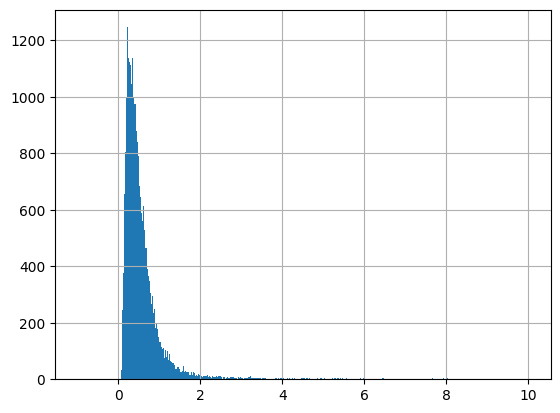

In [ ]:
error_df.Reconstruction_error.hist(bins=1000, range=(-1,10))

La precision y el recall son muy importantes, y a veces hay que buscar el modo de optimizarlos escogiendo un threshold adecuado.

El limite a escoger (threshold) depende de que se desea del modelo. Escoger si preferimos dejar pasar un fraude por etiquetarlo mal o si preferimos etiquetar mas como fraude e invertir en solucionarlos aunque no sean fraude.

In [ ]:
precision_rt, recall_rt, threshold_rt = precision_recall_curve(error_df.True_class, error_df.Reconstruction_error)
px.scatter(x = recall_rt, y = precision_rt, title = 'Precision vs. Recall',
           labels = {
             'x': 'Recall',
             'y': 'Precision'
           })

In [ ]:
len(threshold_rt)

56357

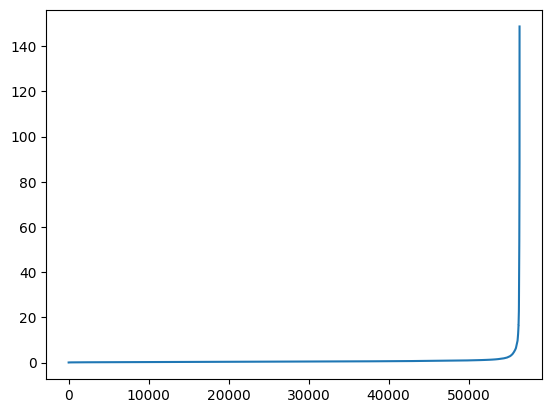

In [ ]:
# Grafica de todos los limites (threshold)
plt.plot(threshold_rt[0:])
plt.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = threshold_rt, y = precision_rt[1:], name = "Precision"))
fig.add_trace(go.Scatter(x = threshold_rt, y = recall_rt[1:], name = "Recall"))

fig.update_layout(
    title = 'Precision y Recall para diferentes umbrales',
    xaxis_title = 'Umbral (threshold)',
    yaxis_title = 'Precision/Recall',
    hovermode="x unified"
)

fig.show()

In [ ]:
threshold_fixed = 50

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
                    x = error_df[error_df.True_class == 0].index.to_numpy(),
                    y = error_df[error_df.True_class == 0].Reconstruction_error,
                    mode = 'markers',
                    name = 'Normal'))

fig.add_trace(go.Scatter(
                    x = error_df[error_df.True_class == 1].index.to_numpy(),
                    y = error_df[error_df.True_class == 1].Reconstruction_error,
                    mode = 'markers',
                    name = 'Fraude'))
fig.add_hline(threshold_fixed, annotation_text = 'Umbral fijo', line_dash = 'dash')

fig.update_layout(
    title = 'Error de reconstrucción para distintas clases',
    yaxis_title = 'Error de Reconstrucción (MSE)',
    xaxis_title = 'Índice del punto'
)
fig.show()

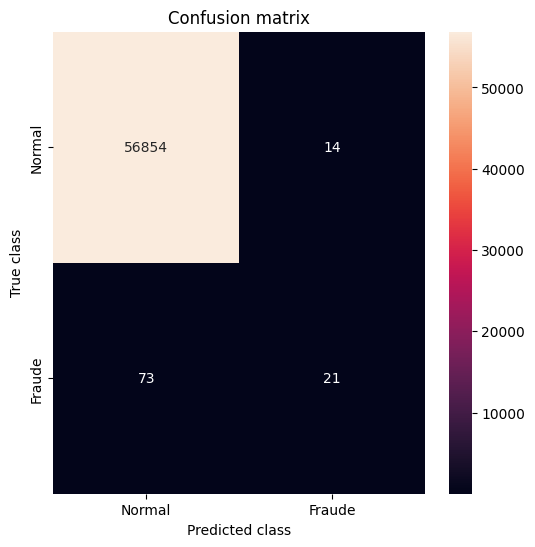

In [ ]:
pred_y = [1 if e > 50 else 0 for e in error_df.Reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.True_class, pred_y)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, xticklabels=['Normal', 'Fraude'], yticklabels=['Normal', 'Fraude'], annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [ ]:
print(classification_report(y_test, pred_y, digits = 4))

              precision    recall  f1-score   support

           0     0.9987    0.9998    0.9992     56868
           1     0.6000    0.2234    0.3256        94

    accuracy                         0.9985     56962
   macro avg     0.7994    0.6116    0.6624     56962
weighted avg     0.9981    0.9985    0.9981     56962



# Ejercicios

- Agregar más capas al encoder y/o al decoder y comparar los resultados obtenidos. Agregar muchas capas al modelo puede hacer que se sobreajuste. Una manera de mitigarlo es agregando regularización o capas Droupout. Si considera que su modelo tiene sobreajuste agregue cualquiera de las dos o elimine capas.
- ¿Cuál es la utilidad de las funciones de activación? ¿Qué operaciones hacen las distintas [funciones de activación que tiene Keras](https://keras.io/api/layers/activations/)?
- Pruebe con diferentes funciones de activación y evalue los resultados. Las funciones de activación que tiene el modelo son tanh (tangente hiperbólica) y ReLU (Rectified Linear Unit).

# Ligas

- [Post Original](https://blogs.oracle.com/ai-and-datascience/post/fraud-detection-using-autoencoders-in-keras-with-a-tensorflow-backend)

- Info. sobre pulir hiperparámetros (batch_size, learn_rate, epochs,...)
  
  *   https://www.oreilly.com/library/view/hands-on-machine-learning/9781491962282/
  *   https://www.oreilly.com/library/view/natural-language-processing/9781484242674/

